## **1. Import thư viện**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')


## **2. Đọc dữ liệu và khám phá tổng quan**

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")


In [3]:
print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
print("Dữ liệu số")
display(train.describe())


Dữ liệu số


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Dữ liệu object")
train.describe(include=['object'])


Dữ liệu object


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


Sex và Embarked có 2-3 dữ liệu độc nhất -> có thể dùng để huấn luyện mô hình

In [6]:
display(train.head())
display(test.head())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


,feature,missing_count,missing_percent
0,Cabin,687,77.10
1,Age,177,19.87
2,Embarked,2,0.22


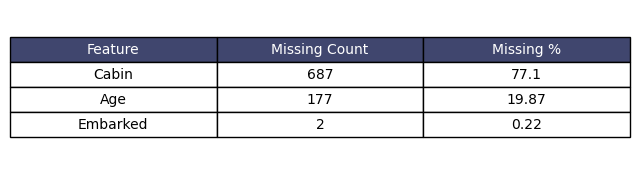

In [ ]:
# Bảng thống kê giá trị thiếu
missing_counts = train.isnull().sum()
missing_percent = (missing_counts / len(train) * 100).round(2)
missing_df = pd.DataFrame({
    'feature': missing_counts.index,
    'missing_count': missing_counts.values,
    'missing_percent': missing_percent.values
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)

if missing_df.empty:
    print("Không có giá trị thiếu trong dữ liệu.")
else:

    # Hiển thị dataframe
    display(missing_df.reset_index(drop=True))

    # Vẽ bảng matplotlib từ dataframe
    fig, ax = plt.subplots(figsize=(8, max(2, 0.5 * len(missing_df))))
    ax.axis('off')
    table_data = missing_df.reset_index(drop=True).values
    col_labels = ['Feature', 'Missing Count', 'Missing %']
    table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    # tô nền header
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#40466e')
            cell._text.set_color('white')
    plt.show()


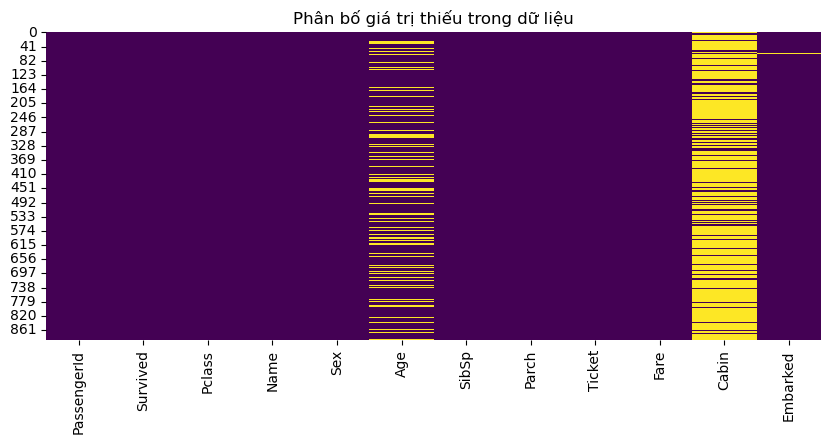

In [8]:
plt.figure(figsize=(10,4))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("Phân bố giá trị thiếu trong dữ liệu")
plt.show()


Tỷ lệ sống sót trong tập huấn luyện:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


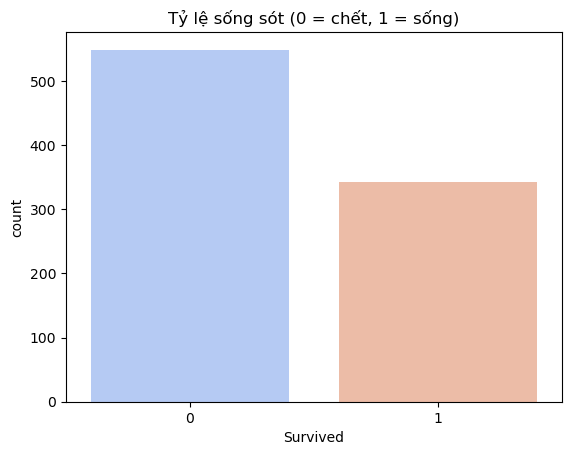

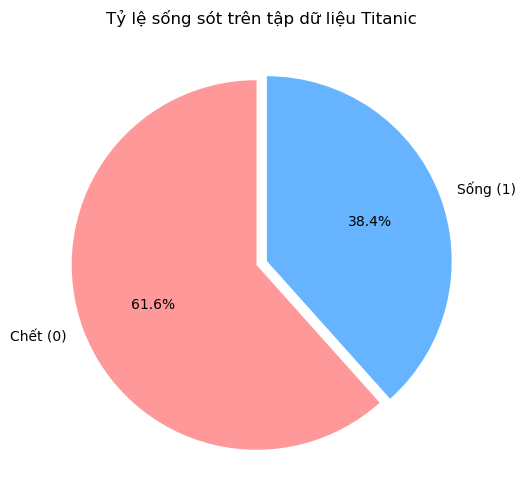

In [9]:
print("Tỷ lệ sống sót trong tập huấn luyện:")
print(train['Survived'].value_counts(normalize=True))

sns.countplot(x='Survived', data=train, palette='coolwarm')
plt.title("Tỷ lệ sống sót (0 = chết, 1 = sống)")
plt.show()

counts = train['Survived'].value_counts().sort_index()
labels = ['Chết (0)', 'Sống (1)']
colors = ['#ff9999', '#66b3ff']
plt.figure(figsize=(6,6))
counts.plot.pie(labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.03,0.03), shadow=False)
plt.ylabel('')
plt.title('Tỷ lệ sống sót trên tập dữ liệu Titanic')
plt.show()


## **3. Phân tích khám phá dữ liệu**

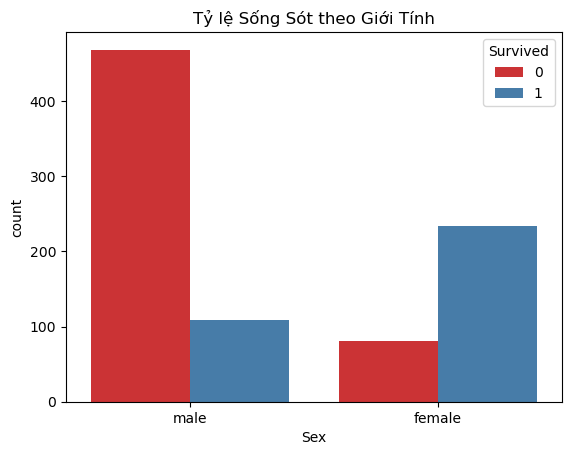

In [10]:
sns.countplot(x='Sex', hue='Survived', data=train, palette='Set1')
plt.title('Tỷ lệ Sống Sót theo Giới Tính')
plt.show()


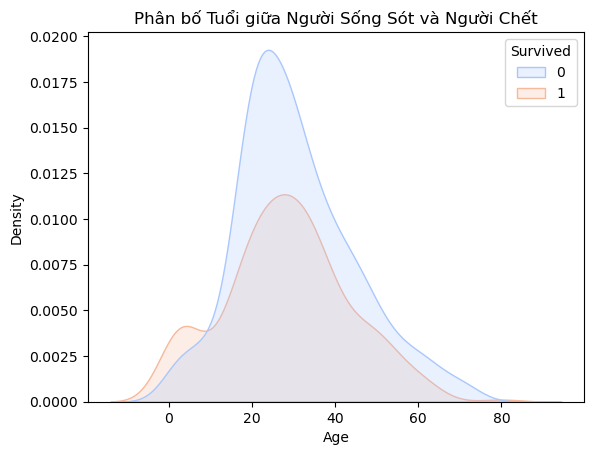

In [11]:
sns.kdeplot(data=train, x='Age', hue='Survived', fill=True, palette='coolwarm')
plt.title('Phân bố Tuổi giữa Người Sống Sót và Người Chết')
plt.show()


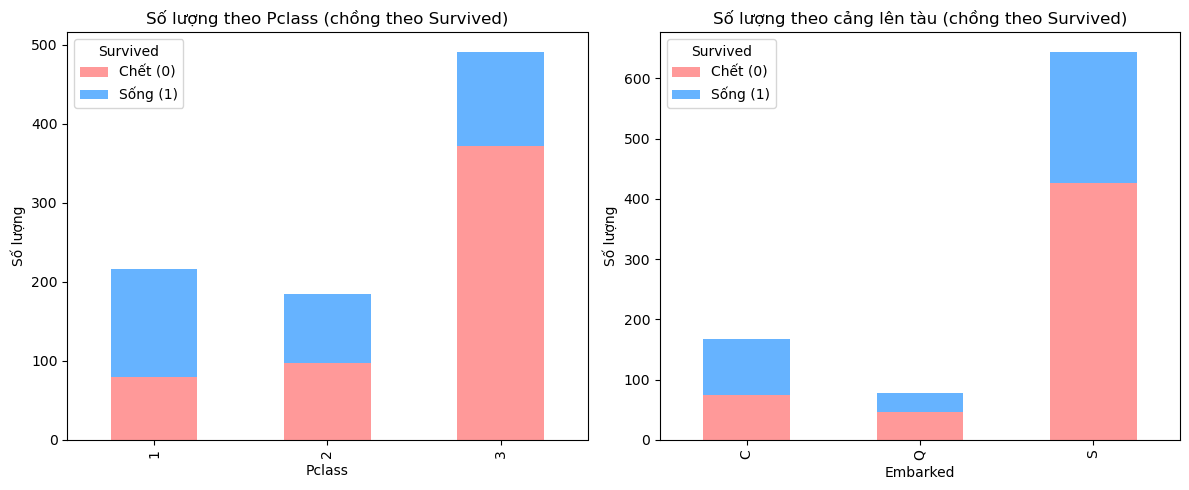

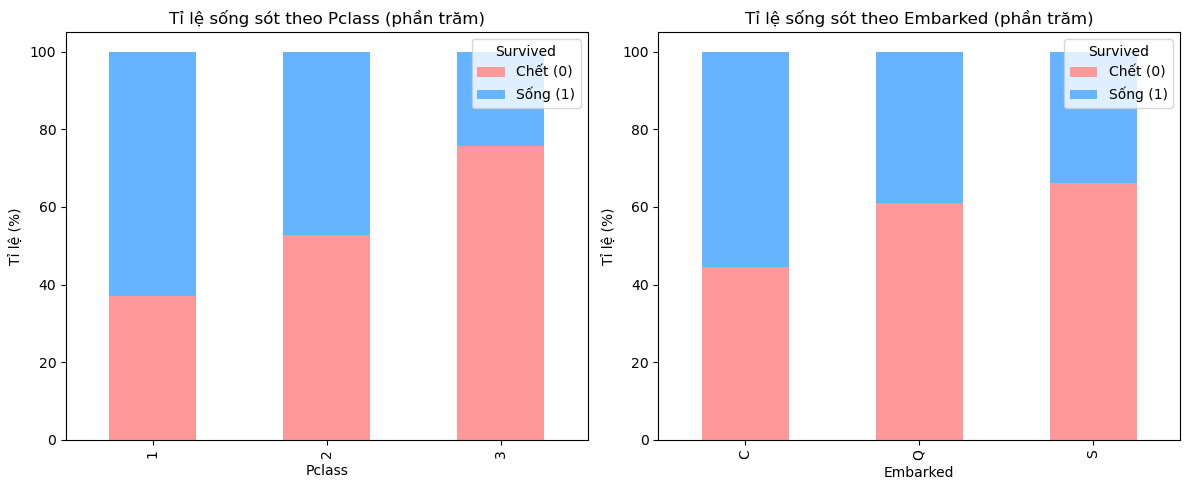

In [15]:
# Biểu đồ cột chồng (counts) cho Pclass và Embarked
counts_pclass = train.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
counts_emb = train[train['Embarked'].notna()].groupby(['Embarked', 'Survived']).size().unstack(fill_value=0).reindex(emb_order)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Pclass
counts_pclass.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Số lượng theo Pclass (chồng theo Survived)')
axes[0].legend(['Chết (0)', 'Sống (1)'], title='Survived')

# Embarked (theo thứ tự emb_order)
counts_emb.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_xlabel('Embarked')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Số lượng theo cảng lên tàu (chồng theo Survived)')
axes[1].legend(['Chết (0)', 'Sống (1)'], title='Survived')

plt.tight_layout()
plt.show()

# Nếu muốn biểu diễn theo phần trăm thay vì counts:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
pct_pclass = counts_pclass.div(counts_pclass.sum(axis=1), axis=0) * 100
pct_emb = counts_emb.div(counts_emb.sum(axis=1), axis=0) * 100

pct_pclass.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_ylabel('Tỉ lệ (%)')
axes[0].set_title('Tỉ lệ sống sót theo Pclass (phần trăm)')
axes[0].legend(['Chết (0)', 'Sống (1)'], title='Survived')

pct_emb.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=axes[1])
axes[1].set_ylabel('Tỉ lệ (%)')
axes[1].set_title('Tỉ lệ sống sót theo Embarked (phần trăm)')
axes[1].legend(['Chết (0)', 'Sống (1)'], title='Survived')

plt.tight_layout()
plt.show()


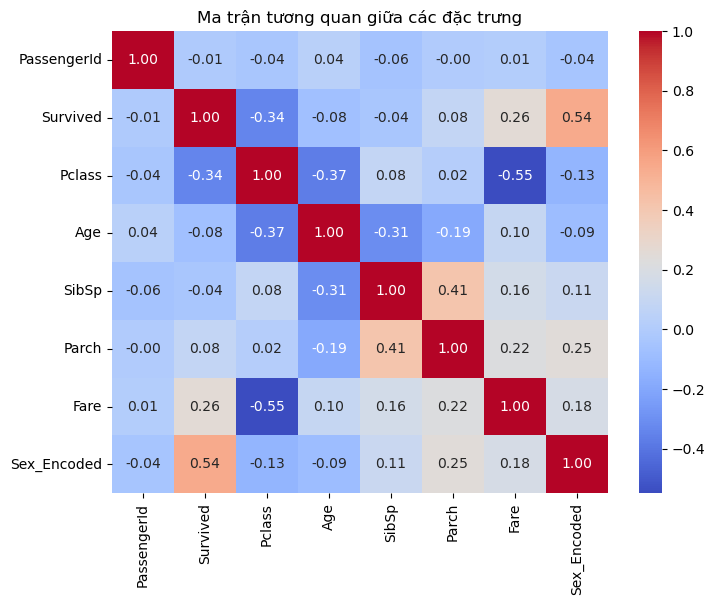

In [12]:
train_temp = train.copy()
train_temp['Sex_Encoded'] = train_temp['Sex'].map({'male': 0, 'female': 1})
train_temp = pd.concat([train_temp], axis=1)
plt.figure(figsize=(8,6))
sns.heatmap(train_temp.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()
